In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from pyfaidx import Fasta
import a_fasta2CpG
import io_informME

In [2]:
import io_informME

# Test Bam to ME mat


In [4]:
import pysam
import matplotlib.pyplot as plt

bam_path_oocyte = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam/PM_24_3-r2_trimmed_bismark_bt2_sm.bam"
bam_path_sperm = "/Users/tnegre/Desktop/trial_informme/sperm/bam_example/MSUS23-F1-2_S20_R1_val_1_bismark_bt2_pe_sm.bam"

plot read length distribution

Total mapped reads: 12712836
Total unmapped reads: 0


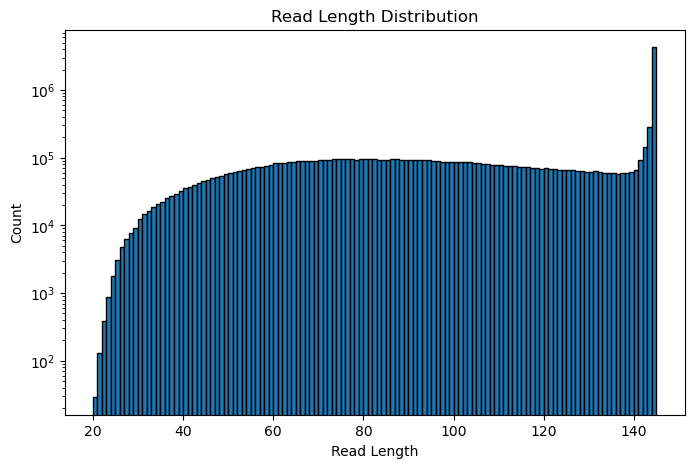

In [7]:
read_lengths = []
total_reads = 0
not_mapped = 0

with pysam.AlignmentFile(bam_path_oocyte, "rb") as bamfile:
    for read in bamfile.fetch(until_eof=True):
        if not read.is_unmapped:
            total_reads += 1
            read_lengths.append(read.query_length)
        else:
            not_mapped += 1 

print(f"Total mapped reads: {total_reads}")
print(f"Total unmapped reads: {not_mapped}")

# Plot distribution of read lengths
plt.figure(figsize=(8, 5))
plt.hist(read_lengths, bins=range(min(read_lengths), max(read_lengths) + 1), edgecolor='black')
plt.title('Read Length Distribution')
plt.xlabel('Read Length')
plt.ylabel('Count')
plt.yscale('log')
plt.show()


Plot mapq distribution

In [ ]:
####

In [8]:
import utils_informME
import io_informME
import a_fasta2CpG

import numpy as np
import pandas as pd

In [ ]:
CpG_ref_folder_path = "/Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg"
bam_file_path = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam/PM_24_3-r2_trimmed_bismark_bt2_sm.bam"


In [ ]:
chr_name = "chr1"
region_length = 3000

In [ ]:
next(iter(df_CpGs_filtered_per_region))

Get ME matrices for one bam file in one chr

In [ ]:
region_lim, df_CpGs_region = next(iter(df_CpGs_filtered_per_region))
# Loop through your regions
start = int(region_lim.left)
end = int(region_lim.right)
region_str = f"{chr_name}:{start}-{end}"
# PySAM fetch: note end is exclusive
reads = bam.fetch(chr_name, start, end)


In [ ]:
reads = list(reads)

reads

In [ ]:
reads = CpGmat._deduplicate_reads(reads)


In [ ]:
reads

In [ ]:
min_phred_score = 0
paired_ends = False
selected_reads = []
for read in reads:
    if read.mapping_quality < min_phred_score:
        continue
    if paired_ends:
        # Only include properly paired reads, both ends mapped, not duplicate, not secondary, not chimeric
        # -F 3328 excludes PCR duplicates, secondary alignments, and 
        # chimeric alignments [3328 = (2^8)+(2^10)+(2^11)].
        if not (read.is_proper_pair and not read.is_secondary and not read.is_supplementary):
            continue
    else:
        # Exclude unpaired, secondary, supplementary
        if read.is_paired or read.is_secondary or read.is_supplementary:
            continue
    selected_reads.append(read)

In [ ]:
selected_reads

In [ ]:
n_reads = len(selected_reads)
if n_reads == 0 or n_reads is None:
    print(f"All reads were filtered out in {region_str}")
if n_reads == 5000:
    print(f"Too many reads mapped to region {region_str}")

In [ ]:
selected_reads


In [ ]:
df_CpGs_region

In [ ]:
n_reads = len(selected_reads)
n_CpGs = len(df_CpGs_region)

In [ ]:
n_CpGs

In [ ]:
n_reads

In [ ]:
ME_mat = -1 * np.ones((n_reads, n_CpGs))

In [ ]:
read = selected_reads[0]

In [ ]:
has_idnshp = bool(set('IDNSHP') & set(read.cigarstring))
print(has_idnshp)

In [ ]:
cigar = read.cigarstring
print(cigar)

In [ ]:
positions = list(df_CpGs_region['position'])

In [ ]:
seq = read.query_sequence

In [ ]:
import pysam

xm_tag = read.get_tag('XM')

seq = read.query_sequence
print(seq)
ref_pos = read.get_reference_positions()  # reference positions covered by read
print(ref_pos)

for i, (meth_status, pos) in enumerate(zip(xm_tag, ref_pos)):
    if meth_status in ['Z', 'z']:  # Z: methylated CpG, z: unmethylated CpG
        # Only keep CpG contexts
        cpg_status = 'methylated' if meth_status == 'Z' else 'unmethylated'
        print(f"{read.reference_name}\t{pos}\t{read.query_name}\t{cpg_status}")


In [ ]:
positions

In [ ]:
reads

In [ ]:
positions = list(df_CpGs_region['position'])
position_to_column = {pos: idx for idx, pos in enumerate(positions)}


In [ ]:
position_to_column

In [ ]:
print(position_to_column.get(0))

In [ ]:
# Build lookup: CpG position (1-based) --> column in ME_mat
position_to_column = {pos: col_idx for col_idx, pos in enumerate(positions)}
for read_index, read in enumerate(reads):  # reads = iterable/list of pysam AlignedSegment
    try:
        XM = read.get_tag('XM')
    except KeyError:
        print(f"No XM tag for methylation info in read {read}")
        continue  # No XM tag, skip this read

    ref_pos = read.get_reference_positions()  # list of 0-based positions

    for i, (meth_call, pos0) in enumerate(zip(XM, ref_pos)):
        if meth_call in ("Z", "z"):
            pos1 = pos0 + 1  # convert to 1-based
            col = position_to_column.get(pos1)
            if col is not None:
                ME_mat[read_index, col] = 1 if meth_call == "Z" else 0


In [ ]:
ME_mat

In [ ]:
reads

In [ ]:
for read in reads:  # 'reads' is your list of pysam AlignedSegment objects
    print(read.query_name, read.is_reverse)

In [ ]:
read = reads[1]
try:
    XM = read.get_tag('XM')
except KeyError:
    print(f"No XM tag for methylation info in read {read}")

ref_pos = read.get_reference_positions()  # list of 0-based positions
print(ref_pos)
print(XM)
print(read.query_sequence)
for i, (meth_call, pos0) in enumerate(zip(XM, ref_pos)):
    if meth_call in ("Z", "z"):
        pos1 = pos0 + 1  # convert to 1-based
        col = position_to_column.get(pos1)
        if col is not None:
            ME_mat[read_index, col] = 1 if meth_call == "Z" else 0


In [ ]:
fa["chr1"][0]

In [ ]:
ref_seq = fa["chr1"][ref_pos[0]:ref_pos[-1]+1]


In [ ]:
for read in reads:  # 'reads' is your list of pysam AlignedSegment objects
    print(read.query_name, read.is_reverse)

    ref_pos = read.get_reference_positions()  # list of 0-based positions

    read_seq = read.query_sequence
    print(ref_pos[0],ref_pos[-1]+1)
    ref_seq = fa["chr1"][ref_pos[0]:ref_pos[-1]+1]
    XM = read.get_tag('XM')

    read_me = XM
    print(read_seq)
    print(ref_seq)
    print(read_me)
    print(read.mapping_quality)

In [57]:
from Bio.Seq import Seq

for read in reads:
    print(f"{read.query_name} is_reverse={read.is_reverse}")
    ref_pos = read.get_reference_positions()
    read_seq = read.query_sequence
    ref_seq = fa["chr1"][ref_pos[0]:ref_pos[-1]+1]
    XM = read.get_tag('XM')


    if read.is_reverse:
        print("Rc     read:", str(Seq(read_seq).reverse_complement()))
        print("Origin read:", read_seq)
        print("Refece     :", ref_seq)
        print("           :", XM)
    else:
        print("Origin read:", read_seq)
        print("Reference  :", ref_seq)
        print("           :", XM)

    print("---")


E00526:575:HJLY3CCX2:7:1205:16904:19205_2:N:0:AGTTCC is_reverse=False
Origin read: CTTCTCTTTTATTGGGGAATTGAGTTTATTGATGTTAAGAGAAATTAAAGATAAGTAATTGTTGTTTTTTGTTATTTTTGTTGTTAAATTTGGG
Reference  : ATGTCTTTTTACTGGGGAATTGAGTCCATTGATGTTAAGAGAAATTAAAGACAAGTAATTGTTGCTTCCTGTTATTTTTGTTGTTAAATTTGGG
           : ....h......x.............hh........................h............h..hx.........................
---
E00526:575:HJLY3CCX2:7:1222:4624:46701_2:N:0:AGTTCC is_reverse=True
Rc     read: AAGTAATATAGTTTTTGGGATAGGTAGAAGAGTTATAGTTTTTGGGATAGGTTTTGTTTTGGGTTG
Origin read: CAACCCAAAACAAAACCTATCCCAAAAACTATAACTCTTCTACCTATCCCAAAAACTATATTACTT
Refece     : CAGCCCAAAACAGGGCCTGTCCCAGAAGCTGTGTCTCTTCTGCCTATCCCAGAAGCTGTATTGCTT
           : ..x.........xhh...x.....x..h..x.h........x.........x..h..x....h...
---
E00526:575:HJLY3CCX2:7:2206:8836:34096_2:N:0:AGTTCC is_reverse=False
Origin read: AGTAGGAAATGGGGTATGTTTTAGAAGTTGTTTTGTTTTTGTAATTTATATGTTTAGTTTTTG
Reference  : AGCAGGAAACGGGGTATGTCCCAGAAGCTGTCTTGCTTCTGCAATCCACAT

In [101]:
bam_path_sperm = "/Users/tnegre/Desktop/trial_informme/sperm/bam_example/sub_F1_2_S20.bam"

In [102]:
reads = list(io_informME.load_bam(bam_path_sperm))

In [ ]:
from Bio.Seq import Seq

for read in reads:
    print(f"{read.query_name} is_reverse={read.is_reverse}")
    ref_pos = read.get_reference_positions()
    read_seq = read.query_sequence
    ref_seq = fa["chr1"][ref_pos[0]:ref_pos[-1]+1]
    XM = read.get_tag('XM')


    if read.is_reverse:
        print("Rc     read:", str(Seq(read_seq).reverse_complement()))
        print("Origin read:", read_seq)
        print("Refece     :", ref_seq)
        print("           :", XM)
        print(read.is_proper_pair)
    else:
        print("Origin read:", read_seq)
        print("Reference  :", ref_seq)
        print("           :", XM)
        print(read.is_proper_pair)

    print("---")

LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG is_reverse=False
Origin read: TAAAGTAAGTAAGTATTTTTTATTTGGGATGTTTTTGTGGTGGGTTTTGTTTTTATTTTATAATGTTAGGTGATTGGTTAGTTTTATGATTAATGAAGGATGATAGAATTTTTTAGGGAAGTTATTATATAAGTAAT
Reference  : TAAAGCAAGTAAGTATTTCTCATTTGGGATGTTTTTGTGGTGGGCTTTGTTTCTATCTTACAATGTCAGGTGATTGGCTAGCCTTATGACTAATGAAGGATGATAGAATTCTTTAGGGAAGCTATCATATAAGCAAC
           : .....h............h.h.......................h.......h...h...h.....x..........h...hh......h....................h..........h...h.......h..h
True
---
LH00289:227:22VFG2LT3:3:1213:38345:7297_1:N:0:CTTCACTG+GTCCTAAG is_reverse=False
Origin read: TAAAGTAAGTAAGTATTTTTTATTTGGGATGTTTTTGTGGTGGGTTTTGTTTTTATTTTATAATGTTAGGTGATTGGTTAGTTTTATGATTAATGAAGGATGATAGAATTTTTTAGGGAAGTTATTATATAAGTAAT
Reference  : TAAAGCAAGTAAGTATTTCTCATTTGGGATGTTTTTGTGGTGGGCTTTGTTTCTATCTTACAATGTCAGGTGATTGGCTAGCCTTATGACTAATGAAGGATGATAGAATTCTTTAGGGAAGCTATCATATAAGCAAC
           : .....h............h.h.......................h.......h...h...

In [103]:
import bam_process

In [104]:
paired_ends = True

In [ ]:
dedup_reads = bam_process.deduplicate_reads(reads)
for read in dedup_reads:
    if read.mapping_quality < min_phred_score:
        continue
    if paired_ends:
        if not (read.is_proper_pair and not read.is_secondary and not read.is_supplementary):
            continue
    else:
        if read.is_paired or read.is_secondary or read.is_supplementary:
            continue
    selected_reads.append(read)

In [ ]:
from collections import defaultdict


In [ ]:
dupe_groups = defaultdict(list)
for read in reads:
    # For paired-end, only process one read per pair (commonly read1)
    if read.is_paired and read.is_proper_pair and read.is_read1:
        # Template start = min(read start, mate start)
        # Template end = max(read end, mate end)
        t_start = min(read.reference_start, read.next_reference_start)
        # read.reference_end gives the end of this read
        # mate end estimated as next_reference_start + read.query_length (may not be precise for split reads)
        t_end = max(read.reference_end, read.next_reference_start + read.query_length)
        key = (read.reference_name, t_start, t_end, read.is_reverse)
    else:
        # Single-end or unmapped/other, use read start, strand
        key = (read.reference_name, read.reference_start, read.is_reverse)
    dupe_groups[key].append(read)

unique_reads = []
for group in dupe_groups.values():
    best_read = max(group, key=lambda r: r.mapping_quality)
    unique_reads.append(best_read)

In [105]:
len(reads)

23

In [107]:
dedup_reads = bam_process.deduplicate_reads(reads)
len(dedup_reads)

18

In [128]:
pairs = 0
read1_list = 0
read1_names = []
read2_list = 0
read2_names = []
for read in reads:
    pairs += read.is_proper_pair
    if read.is_read1:
        read1_list +=1
        read1_names.append(read.query_name)

    else:
        read2_list +=1
        read2_names.append(read.query_name)

print('n_pairs:', pairs)
print('n_read1:', read1_list)
print('n_others:', read2_list)

n_pairs: 23
n_read1: 10
n_others: 13


In [129]:
read1_names

['LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:3:1213:38345:7297_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:3:2213:38817:6928_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:7:2164:25364:29151_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:2:1248:31235:23335_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:2:1297:39381:16942_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:2:2180:35497:12969_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:8:1215:37642:18576_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:1:1137:12632:11927_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:5:2130:8794:25145_1:N:0:CTTCACTG+GTCCTAAG']

In [130]:
read2_names

['LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:3:1213:38345:7297_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:3:2213:38817:6928_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:2:1248:31235:23335_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:7:2164:25364:29151_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:2:2180:35497:12969_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:4:1108:41091:28270_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:3:1184:43736:23015_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:4:1166:2507:25947_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:4:1179:45446:28670_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:8:1215:37642:18576_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:1:1137:12632:11927_1:N:0:CTTCACTG+GTCCTAAG',
 'LH00289:227:22VFG2LT3:5:2130:8794:25145_1:N:0:CTTCACTG+GTCCTAAG']

In [ ]:
for read in reads:
    # For paired-end, only process one read per pair (commonly read1)
    if read.is_paired and read.is_proper_pair and read.is_read1:
        t_start = min(read.reference_start, read.next_reference_start)
        t_end = max(read.reference_end, read.next_reference_start + read.query_length)
        key = (read.reference_name, t_start, t_end, read.is_reverse)
    else:
        # Single-end or unmapped/other, use read start, strand
        key = (read.reference_name, read.reference_start, read.is_reverse)
    dupe_groups[key].append(read)

In [134]:
import pysam

target_name = "LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG"
reads = io_informME.load_bam(bam_path_sperm)
matches = [read for read in reads.fetch(until_eof=True) if read.query_name == target_name]

print(f"Number of matches: {len(matches)}")
for read in matches:
    print(read)


Number of matches: 2
LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG	1123	chr1	3999873	42	137M	chr1	3999873	137	TAAAGTAAGTAAGTATTTTTTATTTGGGATGTTTTTGTGGTGGGTTTTGTTTTTATTTTATAATGTTAGGTGATTGGTTAGTTTTATGATTAATGAAGGATGATAGAATTTTTTAGGGAAGTTATTATATAAGTAAT	array('B', [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40])	[('NM', 17), ('MD', '5C12C1C23C7C3C3C5C10C3C0C6C20C10C3C7C2C0'), ('XM', '.....h............h.h.......................h.......h...h...h.....x..........h...hh......h.........

In [135]:
for read in matches:
    print(f"flag: {read.flag}, is_secondary: {read.is_secondary}, is_supplementary: {read.is_supplementary}, is_read1: {read.is_read1}, is_read2: {read.is_read2}")


flag: 1123, is_secondary: False, is_supplementary: False, is_read1: True, is_read2: False
flag: 1171, is_secondary: False, is_supplementary: False, is_read1: False, is_read2: True


In [136]:
def decode_flag(flag):
    explanations = []
    if flag & 0x1: explanations.append("Read paired")
    if flag & 0x2: explanations.append("Read mapped in proper pair")
    if flag & 0x4: explanations.append("Read unmapped")
    if flag & 0x8: explanations.append("Mate unmapped")
    if flag & 0x10: explanations.append("Read reverse strand")
    if flag & 0x20: explanations.append("Mate reverse strand")
    if flag & 0x40: explanations.append("First in pair")
    if flag & 0x80: explanations.append("Second in pair")
    if flag & 0x100: explanations.append("Not primary alignment (secondary)")
    if flag & 0x200: explanations.append("Read fails platform/vendor quality checks")
    if flag & 0x400: explanations.append("PCR or optical duplicate")
    if flag & 0x800: explanations.append("Supplementary alignment")
    return explanations

for read in matches:
    print(f"Flag: {read.flag}")
    print("Decoded:", decode_flag(read.flag))
    print()


Flag: 1123
Decoded: ['Read paired', 'Read mapped in proper pair', 'Mate reverse strand', 'First in pair', 'PCR or optical duplicate']

Flag: 1171
Decoded: ['Read paired', 'Read mapped in proper pair', 'Read reverse strand', 'Second in pair', 'PCR or optical duplicate']



In [137]:
from Bio.Seq import Seq

for read in matches:
    print(f"{read.query_name} is_reverse={read.is_reverse}")
    ref_pos = read.get_reference_positions()
    read_seq = read.query_sequence
    ref_seq = fa["chr1"][ref_pos[0]:ref_pos[-1]+1]
    XM = read.get_tag('XM')


    if read.is_reverse:
        print("Rc     read:", str(Seq(read_seq).reverse_complement()))
        print("Origin read:", read_seq)
        print("Refece     :", ref_seq)
        print("           :", XM)
        print(read.is_proper_pair)
    else:
        print("Origin read:", read_seq)
        print("Reference  :", ref_seq)
        print("           :", XM)
        print(read.is_proper_pair)

    print("---")


LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG is_reverse=False
Origin read: TAAAGTAAGTAAGTATTTTTTATTTGGGATGTTTTTGTGGTGGGTTTTGTTTTTATTTTATAATGTTAGGTGATTGGTTAGTTTTATGATTAATGAAGGATGATAGAATTTTTTAGGGAAGTTATTATATAAGTAAT
Reference  : TAAAGCAAGTAAGTATTTCTCATTTGGGATGTTTTTGTGGTGGGCTTTGTTTCTATCTTACAATGTCAGGTGATTGGCTAGCCTTATGACTAATGAAGGATGATAGAATTCTTTAGGGAAGCTATCATATAAGCAAC
           : .....h............h.h.......................h.......h...h...h.....x..........h...hh......h....................h..........h...h.......h..h
True
---
LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG is_reverse=True
Rc     read: ATTACTTATATAATAACTTCCCTAAAAAATTCTATCATCCTTCATTAATCATAAAACTAACCAATCACCTAACATTATAAAATAAAAACAAAACCCACCACAAAAACATCCCAAATAAAAAATACTTACTTACTTTA
Origin read: TAAAGTAAGTAAGTATTTTTTATTTGGGATGTTTTTGTGGTGGGTTTTGTTTTTATTTTATAATGTTAGGTGATTGGTTAGTTTTATGATTAATGAAGGATGATAGAATTTTTTAGGGAAGTTATTATATAAGTAAT
Refece     : TAAAGCAAGTAAGTATTTCTCATTTGGGATGTTTTTGTGGTGGGCTTTGTTTCTATCTTA

In [147]:
reads = io_informME.load_bam(bam_path_sperm)

In [148]:
for read in reads:
    if read.is_duplicate:
        print(read.query_name, "is a duplicate")
    else:
        print(read.query_name, "is not")


LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG is a duplicate
LH00289:227:22VFG2LT3:3:1213:38345:7297_1:N:0:CTTCACTG+GTCCTAAG is a duplicate
LH00289:227:22VFG2LT3:3:2213:38817:6928_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT3:3:1212:40425:29455_1:N:0:CTTCACTG+GTCCTAAG is a duplicate
LH00289:227:22VFG2LT3:3:1213:38345:7297_1:N:0:CTTCACTG+GTCCTAAG is a duplicate
LH00289:227:22VFG2LT3:3:2213:38817:6928_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT3:2:1248:31235:23335_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT3:7:2164:25364:29151_1:N:0:CTTCACTG+GTCCTAAG is a duplicate
LH00289:227:22VFG2LT3:2:1248:31235:23335_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT3:7:2164:25364:29151_1:N:0:CTTCACTG+GTCCTAAG is a duplicate
LH00289:227:22VFG2LT3:2:1297:39381:16942_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT3:2:2180:35497:12969_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT3:2:2180:35497:12969_1:N:0:CTTCACTG+GTCCTAAG is not
LH00289:227:22VFG2LT

In [ ]:
import pysam
bam_path_sorted = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_sorted.bam"

bam_path = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_R1_val_1_bismark_bt2_pe.bam"
fasta_path = "/Users/tnegre/Desktop/trial_informme/mm10_forWGBS/GRCm38.primary_assembly.genome.fa"
fa = pysam.FastaFile(fasta_path)  # Use pysam's FastaFile

with pysam.AlignmentFile(bam_path, "rb") as bam:
    for i, read in enumerate(bam.fetch(until_eof=True)):
        if i > 5:
            break
        read_name = read.query_name
        sequence = read.query_sequence
        strand = "reverse" if read.is_reverse else "forward"
        try:
            xm_tag = read.get_tag("XM")
        except KeyError:
            xm_tag = "NA"
        
        # Only fetch if read is mapped
        if not read.is_unmapped:
            ref_name = read.reference_name
            ref_start = read.reference_start  # 0-based, inclusive
            ref_end = read.reference_end      # 0-based, exclusive
            ref_seq = fa.fetch(ref_name, ref_start, ref_end)
        else:
            ref_seq = "unmapped"

        print(f"{read_name}\n{strand}\n{sequence}\n{xm_tag}\n{ref_seq}\n")


E00526:575:HJLY3CCX2:5:1101:17655:993_1:N:0:NCAGTG
reverse
AATATATCTATAATTTCTTTCCATAAAAACAAAAATATTCTAAAAACAAAAACAAAACTAACTACAATAACAATTACATAATACTAAATACTACAAACCCCACAAAACTTAACAATCTA
...h.h......h...........h..h........h......................x......h.....x..h.........x......x..x........x.....h...x....
AATGTGTCTATAGTTTCTTTCCATGAAGACAAAAATGTTCTAAAAACAAAAACAAAACTGACTATAGTAACAGTTGCATAATTCTGAATACTGCAGACCCCACAGAACTTGACAGTCTA

E00526:575:HJLY3CCX2:5:1101:17655:993_1:N:0:NCAGTG
forward
ATATATCTATAATTTCTTTCCATAAAAACAAAAATATTCTAAAAACAAAAACAAAACTAACTACAATAACAATTACATAATACTAAATACTACAAACCCCACAAAACTTAACAATCTAT
..h.h......h...........h..h........h......................x......h.....x..h.........x......x..x........x.....h...x.....
ATGTGTCTATAGTTTCTTTCCATGAAGACAAAAATGTTCTAAAAACAAAAACAAAACTGACTATAGTAACAGTTGCATAATTCTGAATACTGCAGACCCCACAGAACTTGACAGTCTAG

E00526:575:HJLY3CCX2:5:1101:6076:1010_1:N:0:NCAGTG
reverse
AATAAAATTAACCAAATAACTTTATAATTAAAAAACTTACTCTTACAAAAAACTTACAAATTACACTACCTCCAACTCCAAAAAGAATCCAATATCCTCTT

In [9]:
bam_path_sorted = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_sorted.bam"

fasta_path = "/Users/tnegre/Desktop/trial_informme/mm10_forWGBS/GRCm38.primary_assembly.genome.fa"
fa = pysam.FastaFile(fasta_path)  # Use pysam's FastaFile

with pysam.AlignmentFile(bam_path_sorted, "rb") as bam:
    for i, read in enumerate(bam.fetch(until_eof=True)):
        if i > 100:
            break
        read_name = read.query_name
        sequence = read.query_sequence
        strand = "reverse" if read.is_reverse else "forward"
        try:
            xm_tag = read.get_tag("XM")
        except KeyError:
            xm_tag = "NA"
        
        # Only fetch if read is mapped
        if not read.is_unmapped:
            ref_name = read.reference_name
            ref_start = read.reference_start  # 0-based, inclusive
            ref_end = read.reference_end      # 0-based, exclusive
            ref_seq = fa.fetch(ref_name, ref_start, ref_end)
        else:
            ref_seq = "unmapped"

        print(f"{read_name}\n{strand}\n{sequence}\n{xm_tag}\n{ref_seq}\n")

E00526:575:HJLY3CCX2:5:2106:31040:63841_1:N:0:ACAGTG
forward
TAGTTATTAGTTTGGTTGATTTTTTGAATATTTTTTTTTGTTTTTATTTGGTTGATTTTAGTTTTGAGTTTGATTATTTTTTGTTGTTTATTTATTTTGGGTGAATTTGTTTTTTTTTGTTTTAGAGTTTCTAGTTTTGTTGTTTGGTTG
x..h..h..............h...........h.........hh.h...........x..h.x...............hx..x...h..h.h..h.............h..hh.......h.....h..H........x...x...x..
CAGCTACTATTTTGGTTGATTCTTTGAATATTTCTTTTTGTTTCCACTTGGTTGATTTCAGCTCTGAGTTTGATTATTTCCTGCTGTCTACTCATCTTGGGTGAATTTGCTTCCTTTTGTTCTAGAGCTTCTAGATTTGCTGTCAGGCTG

E00526:575:HJLY3CCX2:5:2106:31040:63841_1:N:0:ACAGTG
reverse
ATATTTTTTTTTGTTTTTATTTGGTTGATTTTAGTTTTGAGTTTGATTATTTTTTGTTGTTTATTTATTTTGGGTGAATTTGTTTTTTTTTGTTTTAGAGTTTCTAGTTTTGTTGTTAGGTTGTTAGTGTATATTTTAGTTTTTTTTTGG
......h.........hh.h...........x..h.x...............hx..x...h..h.h..h.............h..hh.......h.....h..H........x...x...x..h.........h.h......hh......
ATATTTCTTTTTGTTTCCACTTGGTTGATTTCAGCTCTGAGTTTGATTATTTCCTGCTGTCTACTCATCTTGGGTGAATTTGCTTCCTTTTGTTCTAGAGCTTCTAGATTTGCTGTCAGGCT

In [ ]:
import pysam

unsorted_bam_path = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_R1_val_1_bismark_bt2_pe.bam"

sorted_bam_path = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_sorted.bam"


fasta_path = "/Users/tnegre/Desktop/trial_informme/mm10_forWGBS/GRCm38.primary_assembly.genome.fa"

# Open files
unsorted_bam = pysam.AlignmentFile(unsorted_bam_path, "rb")
sorted_bam = pysam.AlignmentFile(sorted_bam_path, "rb")
fasta = pysam.FastaFile(fasta_path)

# Build a quick lookup: query_name -> read in sorted BAM
sorted_reads = {read.query_name: read for read in sorted_bam.fetch(until_eof=True)}

for i , read in enumerate(unsorted_bam.fetch(until_eof=True)):
    if i > 500:
        break
    name = read.query_name
    seq = read.query_sequence
    xm = read.get_tag("XM") if read.has_tag("XM") else "NA"
    
    # Find in sorted BAM
    if name in sorted_reads:
        sorted_read = sorted_reads[name]
        sorted_seq = sorted_read.query_sequence
        sorted_xm = sorted_read.get_tag("XM") if sorted_read.has_tag("XM") else "NA"
        
        same_seq = (seq == sorted_seq)
        same_xm = (xm == sorted_xm)
        
        # Reference coordinates
        if not read.is_unmapped:
            ref_name = read.reference_name
            ref_start = read.reference_start
            ref_end = read.reference_end
            ref_seq = fasta.fetch(ref_name, ref_start, ref_end)
        else:
            ref_seq = "unmapped"
        
        if same_seq and same_xm:
            print(f"Read: {name}")
            print(f"Unsorted   | Seq: \n{seq} XM: \n{xm}")
            print(f"Sorted     | Seq: \n{sorted_seq} XM: \n{sorted_xm}")

            print(f"Reference  | {ref_name}:{ref_start}-{ref_end}\n{ref_seq}")
            print("-" * 60)
    else:
        print(f"Read: {name} not found in sorted BAM.")


Read: E00526:575:HJLY3CCX2:5:1101:17655:993_1:N:0:NCAGTG
Unsorted   | Seq: 
ATATATCTATAATTTCTTTCCATAAAAACAAAAATATTCTAAAAACAAAAACAAAACTAACTACAATAACAATTACATAATACTAAATACTACAAACCCCACAAAACTTAACAATCTAT XM: 
..h.h......h...........h..h........h......................x......h.....x..h.........x......x..x........x.....h...x.....
Sorted     | Seq: 
ATATATCTATAATTTCTTTCCATAAAAACAAAAATATTCTAAAAACAAAAACAAAACTAACTACAATAACAATTACATAATACTAAATACTACAAACCCCACAAAACTTAACAATCTAT XM: 
..h.h......h...........h..h........h......................x......h.....x..h.........x......x..x........x.....h...x.....
Reference  | chr17:65710252-65710371
ATGTGTCTATAGTTTCTTTCCATGAAGACAAAAATGTTCTAAAAACAAAAACAAAACTGACTATAGTAACAGTTGCATAATTCTGAATACTGCAGACCCCACAGAACTTGACAGTCTAG
------------------------------------------------------------
Read: E00526:575:HJLY3CCX2:5:1101:6076:1010_1:N:0:NCAGTG
Unsorted   | Seq: 
AATAAAATTAACCAAATAACTTTATAATTAAAAAACTTACTCTTACAAAAAACTTACAAATTACACTACCTCCAACTCCAAAAAGAATCCAATATCCTCTTTAACCTCTACAAACACCTAA

In [7]:
import pysam

bamfile = pysam.AlignmentFile(sorted_bam_path, "rb")
fasta = pysam.FastaFile(fasta_path)
read = next(bamfile.fetch("chr16", 18442842, 18442965))
xm = read.get_tag("XM")

aligned_pairs = read.get_aligned_pairs(with_seq=True)
for i, (read_pos, ref_pos, ref_base) in enumerate(aligned_pairs):
    if read_pos is not None and ref_pos is not None:
        read_base = read.query_sequence[read_pos]
        ref_base = ref_base.upper()
        xm_char = xm[read_pos] if read_pos < len(xm) else "."
        print(f"Read pos {read_pos}, Ref pos {ref_pos}, Read base {read_base}, Ref base {ref_base}, XM: {xm_char}")


Read pos 0, Ref pos 18442842, Read base G, Ref base G, XM: .
Read pos 1, Ref pos 18442843, Read base T, Ref base T, XM: .
Read pos 2, Ref pos 18442844, Read base T, Ref base T, XM: .
Read pos 3, Ref pos 18442845, Read base A, Ref base A, XM: .
Read pos 4, Ref pos 18442846, Read base T, Ref base T, XM: .
Read pos 5, Ref pos 18442847, Read base G, Ref base G, XM: .
Read pos 6, Ref pos 18442848, Read base T, Ref base T, XM: .
Read pos 7, Ref pos 18442849, Read base A, Ref base A, XM: .
Read pos 8, Ref pos 18442850, Read base T, Ref base T, XM: .
Read pos 9, Ref pos 18442851, Read base G, Ref base G, XM: .
Read pos 10, Ref pos 18442852, Read base G, Ref base G, XM: .
Read pos 11, Ref pos 18442853, Read base T, Ref base T, XM: .
Read pos 12, Ref pos 18442854, Read base T, Ref base C, XM: h
Read pos 13, Ref pos 18442855, Read base A, Ref base A, XM: .
Read pos 14, Ref pos 18442856, Read base T, Ref base C, XM: h
Read pos 15, Ref pos 18442857, Read base T, Ref base T, XM: .
Read pos 16, Ref p

In [8]:

bamfile = pysam.AlignmentFile(sorted_bam_path, "rb")
fasta = pysam.FastaFile(fasta_path)
read = next(bamfile.fetch("chr17", 65710252, 65710371))
xm = read.get_tag("XM")

aligned_pairs = read.get_aligned_pairs(with_seq=True)
for i, (read_pos, ref_pos, ref_base) in enumerate(aligned_pairs):
    if read_pos is not None and ref_pos is not None:
        read_base = read.query_sequence[read_pos]
        ref_base = ref_base.upper()
        xm_char = xm[read_pos] if read_pos < len(xm) else "."
        print(f"Read pos {read_pos}, Ref pos {ref_pos}, Read base {read_base}, Ref base {ref_base}, XM: {xm_char}")


Read pos 0, Ref pos 65710251, Read base A, Ref base A, XM: .
Read pos 1, Ref pos 65710252, Read base A, Ref base A, XM: .
Read pos 2, Ref pos 65710253, Read base T, Ref base T, XM: .
Read pos 3, Ref pos 65710254, Read base A, Ref base G, XM: h
Read pos 4, Ref pos 65710255, Read base T, Ref base T, XM: .
Read pos 5, Ref pos 65710256, Read base A, Ref base G, XM: h
Read pos 6, Ref pos 65710257, Read base T, Ref base T, XM: .
Read pos 7, Ref pos 65710258, Read base C, Ref base C, XM: .
Read pos 8, Ref pos 65710259, Read base T, Ref base T, XM: .
Read pos 9, Ref pos 65710260, Read base A, Ref base A, XM: .
Read pos 10, Ref pos 65710261, Read base T, Ref base T, XM: .
Read pos 11, Ref pos 65710262, Read base A, Ref base A, XM: .
Read pos 12, Ref pos 65710263, Read base A, Ref base G, XM: h
Read pos 13, Ref pos 65710264, Read base T, Ref base T, XM: .
Read pos 14, Ref pos 65710265, Read base T, Ref base T, XM: .
Read pos 15, Ref pos 65710266, Read base T, Ref base T, XM: .
Read pos 16, Ref p

In [9]:
import pysam


bam_path = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_sorted.bam"


ref_path = "/Users/tnegre/Desktop/trial_informme/mm10_forWGBS/GRCm38.primary_assembly.genome.fa"

bamfile = pysam.AlignmentFile(bam_path, "rb")
fasta = pysam.FastaFile(ref_path)

# Find one forward and one reverse read
forward_read = None
reverse_read = None

for read in bamfile.fetch(until_eof=True):
    if not read.is_unmapped:
        if not read.is_reverse and forward_read is None:
            forward_read = read
        if read.is_reverse and reverse_read is None:
            reverse_read = read
    if forward_read and reverse_read:
        break

for label, read in [('Forward', forward_read), ('Reverse', reverse_read)]:
    print(f"\n{'='*15} {label} Strand Read {'='*15}")
    print(f"Read name: {read.query_name}")
    print(f"Is reverse: {read.is_reverse}")
    print(f"Read sequence: {read.query_sequence}")
    xm = read.get_tag("XM")
    print(f"XM tag:      {xm}")
    print("Pos | Ref pos | Read base | Ref base | XM")

    # Use the reference name and aligned positions to get ref bases
    aligned_pairs = read.get_aligned_pairs(with_seq=True)
    for i, (read_pos, ref_pos, ref_base) in enumerate(aligned_pairs):
        if read_pos is not None and ref_pos is not None and ref_base is not None:
            read_base = read.query_sequence[read_pos]
            ref_base = ref_base.upper()
            xm_char = xm[read_pos] if read_pos < len(xm) else "."
            print(f"{read_pos:3} | {ref_pos:8} |    {read_base}      |    {ref_base}     | {xm_char}")
    print("="*50)



=============== Forward Strand Read ===============
Read name: E00526:575:HJLY3CCX2:5:2106:31040:63841_1:N:0:ACAGTG
Is reverse: False
Read sequence: TAGTTATTAGTTTGGTTGATTTTTTGAATATTTTTTTTTGTTTTTATTTGGTTGATTTTAGTTTTGAGTTTGATTATTTTTTGTTGTTTATTTATTTTGGGTGAATTTGTTTTTTTTTGTTTTAGAGTTTCTAGTTTTGTTGTTTGGTTG
XM tag:      x..h..h..............h...........h.........hh.h...........x..h.x...............hx..x...h..h.h..h.............h..hh.......h.....h..H........x...x...x..
Pos | Ref pos | Read base | Ref base | XM
  0 |  3000431 |    T      |    C     | x
  1 |  3000432 |    A      |    A     | .
  2 |  3000433 |    G      |    G     | .
  3 |  3000434 |    T      |    C     | h
  4 |  3000435 |    T      |    T     | .
  5 |  3000436 |    A      |    A     | .
  6 |  3000437 |    T      |    C     | h
  7 |  3000438 |    T      |    T     | .
  8 |  3000439 |    A      |    A     | .
  9 |  3000440 |    G      |    T     | .
 10 |  3000441 |    T      |    T     | .
 11 |  3000442 |    T      |   

In [15]:
import pysam

bamfile = pysam.AlignmentFile(dennis_r1_bam, "rb")

# Count all reads
count = 0
for read in bamfile:
    count += 1

bamfile.close()
print("Total reads:", count)


bamfile = pysam.AlignmentFile(dennis_r2_bam, "rb")

# Count all reads
count = 0
for read in bamfile:
    count += 1

bamfile.close()
print("Total reads:", count)

bamfile = pysam.AlignmentFile(chuang_bam, "rb")

# Count all reads
count = 0
for read in bamfile:
    count += 1

bamfile.close()
print("Total reads:", count)

Total reads: 11475238
Total reads: 10131469
Total reads: 8804532


In [12]:
dennis_r1_bam = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam/PM_3_2-r1_trimmed_bismark_bt2_sm.bam"
dennis_r2_bam = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam/PM_3_2-r2_trimmed_bismark_bt2_sm.bam"
chuang_bam = "/Users/tnegre/Desktop/mansuy_server_mnt/mnt/IM/groupMansuy/chuang/MSUS_oocyte_scWGBS_codes/results/01_preprocess/04_bismark_alignment/PM_3_2_sorted.bam"


In [16]:
ref_path = "/Users/tnegre/Desktop/trial_informme/mm10_forWGBS/GRCm38.primary_assembly.genome.fa"

bamfile = pysam.AlignmentFile(dennis_r2_bam, "rb")
fasta = pysam.FastaFile(ref_path)

# Find one forward and one reverse read
forward_read = None
reverse_read = None

for read in bamfile.fetch(until_eof=True):
    if not read.is_unmapped:
        if not read.is_reverse and forward_read is None:
            forward_read = read
        if read.is_reverse and reverse_read is None:
            reverse_read = read
    if forward_read and reverse_read:
        break

for label, read in [('Forward', forward_read), ('Reverse', reverse_read)]:
    print(f"\n{'='*15} {label} Strand Read {'='*15}")
    print(f"Read name: {read.query_name}")
    print(f"Is reverse: {read.is_reverse}")
    print(f"Read sequence: {read.query_sequence}")
    xm = read.get_tag("XM")
    print(f"XM tag:      {xm}")
    print("Pos | Ref pos | Read base | Ref base | XM")

    # Use the reference name and aligned positions to get ref bases
    aligned_pairs = read.get_aligned_pairs(with_seq=True)
    for i, (read_pos, ref_pos, ref_base) in enumerate(aligned_pairs):
        if read_pos is not None and ref_pos is not None and ref_base is not None:
            read_base = read.query_sequence[read_pos]
            ref_base = ref_base.upper()
            xm_char = xm[read_pos] if read_pos < len(xm) else "."
            print(f"{read_pos:3} | {ref_pos:8} |    {read_base}      |    {ref_base}     | {xm_char}")
    print("="*50)


=============== Forward Strand Read ===============
Read name: E00526:575:HJLY3CCX2:5:2106:31040:63841_2:N:0:ACAGTG
Is reverse: False
Read sequence: TATTTTTTTTTGTTTTTATTTGGTTGATTTTAGTTTTGAGTTTGATTATTTTTTGTTGTTTATTTATTTTGGGTGAATTTGTTTTTTTTTGTTTTAGAGTTTCTAGTTTTGTTGTTAGGTTGTTAGTGTATATTTTAGTTTTTTT
XM tag:      .....h.........hh.h...........x..h.x...............hx..x...h..h.h..h.............h..hh.......h.....h..H........x...x...x..h.........h.h......hh..
Pos | Ref pos | Read base | Ref base | XM
  0 |  3000459 |    T      |    T     | .
  1 |  3000460 |    A      |    A     | .
  2 |  3000461 |    T      |    T     | .
  3 |  3000462 |    T      |    T     | .
  4 |  3000463 |    T      |    T     | .
  5 |  3000464 |    T      |    C     | h
  6 |  3000465 |    T      |    T     | .
  7 |  3000466 |    T      |    T     | .
  8 |  3000467 |    T      |    T     | .
  9 |  3000468 |    T      |    T     | .
 10 |  3000469 |    T      |    T     | .
 11 |  3000470 |    G      |    G     | .